# Fase 6: Dinámica de Sistemas — Modelo Stocks-Flujos del Proceso de Pagos
## Prueba Técnica - Análisis de Quejas ARL SURA

**Objetivo**: Modelar el proceso de pagos de incapacidades como un **sistema dinámico** con stocks, flujos y loops de retroalimentación. Esto permite:
1. **Entender** por qué el sistema genera quejas de forma endógena (no solo por eventos externos)
2. **Simular** qué pasa si se interviene en diferentes puntos del sistema
3. **Cuantificar** el impacto de cada intervención a lo largo del tiempo

---
### ¿Por qué Dinámica de Sistemas?

Un análisis de correlación o un modelo ML puede decir *qué está pasando*. La Dinámica de Sistemas explica *por qué el sistema se comporta así* y *qué ocurrirá si intervenimos*:

```
ML/Correlación:         "La recurrencia predice el escalamiento"
Dinámica de Sistemas:   "La recurrencia existe porque la resolución es baja,
                         y la resolución es baja porque la carga operativa 
                         generada por la misma recurrencia consume la capacidad"
                         → El sistema se auto-refuerza hasta saturarse
```

---
### Estructura del notebook
1. Definición del modelo (stocks, flujos, parámetros)
2. Calibración con datos reales
3. Simulación del escenario AS-IS (sistema actual)
4. Simulación TO-BE (con intervenciones)
5. Análisis de sensibilidad
6. Visualizaciones para el dashboard

In [ ]:
import sys
from pathlib import Path

EN_COLAB = 'google.colab' in sys.modules

if EN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_BASE      = Path('/content/drive/MyDrive/sura')
    IMAGES_DIR    = OUT_BASE / 'resume' / 'images'
    DASHBOARD_DIR = OUT_BASE / 'dashboard' / 'public' / 'data'
    print('Entorno: Google Colab')
else:
    BASE_DIR      = Path('..').resolve()
    IMAGES_DIR    = BASE_DIR / 'resume' / 'images'
    DASHBOARD_DIR = BASE_DIR / 'dashboard' / 'public' / 'data'
    print('Entorno: local')

IMAGES_DIR.mkdir(parents=True, exist_ok=True)
DASHBOARD_DIR.mkdir(parents=True, exist_ok=True)
print(f'Imágenes  : {IMAGES_DIR}')
print(f'Dashboard : {DASHBOARD_DIR}')

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.integrate import odeint, solve_ivp
from pathlib import Path
import json

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

print("Librerías cargadas")

Librerías cargadas ✓
scipy disponible para integración numérica de ODEs ✓


## 1. Definición del modelo

### Stocks (inventarios del sistema)

| Stock | Símbolo | Unidades | Descripción |
|-------|---------|----------|-------------|
| Quejas pendientes | `Q` | quejas | Acumulado de quejas sin resolver en el sistema |
| Clientes insatisfechos | `C` | clientes | Base de clientes con experiencia negativa acumulada |
| Presión externa | `P` | unidades | Presión acumulada de Entes de Control (reputacional/regulatoria) |

### Flujos

| Flujo | Símbolo | Dirección | Descripción |
|-------|---------|-----------|-------------|
| Entrada de quejas | `e_quejas` | → Q | Nuevas quejas que entran por mes |
| Resolución | `resolucion` | Q → | Quejas cerradas satisfactoriamente |
| Escalamiento | `escalamiento` | Q → P | Quejas que llegan a Entes de Control |
| Retroalimentación recurrencia | `retroalim_C` | C → Q | Clientes insatisfechos que generan nuevas quejas |
| Drenaje de insatisfacción | `drenaje_C` | C → | Clientes que se recuperan (problema resuelto) |
| Presión de desfogue | `desfogue_P` | P → | Reducción de presión por resolución de casos escalados |

### Loops de retroalimentación

```
LOOP R1 — Espiral de Carga (REFORZADOR — amplifica el problema)
────────────────────────────────────────────────────────────────
Q↑ → capacidad_efectiva↓ → resolucion↓ → Q↑  (ciclo que se auto-amplifica)

LOOP R2 — Recurrencia (REFORZADOR)
────────────────────────────────────────────────────────────────
Q↑ → C↑ → retroalim_C↑ → Q↑  (clientes insatisfechos generan más quejas)

LOOP B1 — Resolución Normal (BALANCEADOR — tiende al equilibrio)
────────────────────────────────────────────────────────────────
Q↑ → resolucion↑ → Q↓  (el sistema resuelve quejas si tiene capacidad)

LOOP B2 — Escalamiento-Presión (BALANCEADOR con retardo)
────────────────────────────────────────────────────────────────
P↑ → priorización_reactiva → resolucion_entes↑ → Q↓ pero C sigue alto
```

In [2]:
# ================================================================
# PARÁMETROS DEL MODELO — calibrados con datos reales (NB01-NB05)
# ================================================================

# --- Parámetros calibrados con datos reales ---

# Entrada de quejas (promedio mensual Jan-May 2025)
ENTRADA_BASE = 337       # quejas nuevas por mes (promedio observado)

# Capacidad de resolución del equipo actual
# Si entran 337/mes y la tasa de escalamiento es 8.5%, 
# el sistema resuelve ~308/mes (337 * 0.915) y escala ~29/mes
CAPACIDAD_BASE = 308     # quejas que el equipo puede resolver/mes en condiciones normales

# Tasa de escalamiento observada
TASA_ESCALAMIENTO = 0.085   # 8.5% de las quejas pendientes escalan por mes

# Factor de carga: cuando Q > CAPACIDAD_BASE, la eficiencia cae
# (sobrecarga reduce la capacidad efectiva)
FACTOR_CARGA = 0.003     # por cada queja extra sobre la capacidad, se pierde 0.3% de eficiencia

# Factor de retroalimentación de recurrencia
# 20.7% de clientes son recurrentes → generan quejas adicionales
# Clientes insatisfechos generan ~0.15 quejas adicionales/cliente/mes
TASA_RETROALIM = 0.15    # quejas/cliente_insatisfecho/mes

# Tasa de drenaje de insatisfacción
# Un cliente resuelto deja de estar insatisfecho con probabilidad 0.3/mes
TASA_DRENAJE_C = 0.30

# Proporción de quejas que generan un cliente insatisfecho
TASA_INSATISFACCION = 0.45  # 45% de quejas no resueltas a tiempo generan cliente insatisfecho

# Condiciones iniciales (estado al inicio del período)
Q0 = 50       # Backlog inicial estimado (quejas acumuladas al inicio de Enero)
C0 = 277      # Clientes insatisfechos iniciales (clientes recurrentes observados)
P0 = 10       # Presión externa inicial (baja)

print("=== PARÁMETROS DEL MODELO ===")
print(f"Entrada base de quejas:      {ENTRADA_BASE} quejas/mes")
print(f"Capacidad de resolución:     {CAPACIDAD_BASE} quejas/mes")
print(f"Tasa de escalamiento:        {TASA_ESCALAMIENTO*100:.1f}%")
print(f"Factor de sobrecarga:        {FACTOR_CARGA} (por queja extra)")
print(f"Tasa de retroalimentación:   {TASA_RETROALIM} quejas/cliente/mes")
print(f"\nCondiciones iniciales:")
print(f"  Backlog Q₀ = {Q0} quejas")
print(f"  Clientes insatisfechos C₀ = {C0}")
print(f"  Presión externa P₀ = {P0}")

=== PARÁMETROS DEL MODELO ===
Entrada base de quejas:      337 quejas/mes
Capacidad de resolución:     308 quejas/mes
Tasa de escalamiento:        8.5%
Factor de sobrecarga:        0.003 (por queja extra)
Tasa de retroalimentación:   0.15 quejas/cliente/mes

Condiciones iniciales:
  Backlog Q₀ = 50 quejas
  Clientes insatisfechos C₀ = 277
  Presión externa P₀ = 10


## 2. Ecuaciones del modelo (ODEs)

Las ecuaciones diferenciales del sistema son:

$$\frac{dQ}{dt} = e_{quejas}(t) + retroalim_C(t) - resolucion(t) - escalamiento(t)$$

$$\frac{dC}{dt} = insatisfaccion(t) - drenaje_C(t)$$

$$\frac{dP}{dt} = escalamiento(t) - desfogue_P(t)$$

Donde:
- $resolucion(t) = CAPACIDAD_{base} \cdot (1 - FACTOR\_CARGA \cdot \max(Q - CAP_{base}, 0))$ ← **Loop R1**
- $retroalim_C(t) = C \cdot TASA\_RETROALIM$ ← **Loop R2**
- $escalamiento(t) = Q \cdot TASA\_ESCALAMIENTO$

In [3]:
def modelo_dinamico(t, estado, params):
    """
    Sistema de ODEs para la Dinámica de Quejas ARL SURA.
    
    Estado: [Q, C, P]
      Q = quejas pendientes (backlog)
      C = clientes insatisfechos
      P = presión externa (Entes de Control)
    
    params: diccionario con parámetros del modelo
    """
    Q, C, P = estado
    Q = max(Q, 0)  # No puede ser negativo
    C = max(C, 0)
    P = max(P, 0)
    
    p = params
    
    # ---- FLUJOS ----
    
    # Entrada de quejas: base + componente de recurrencia
    retroalim_C = C * p['tasa_retroalim']
    entrada_total = p['entrada_base'] + retroalim_C  # Loop R2
    
    # Resolución: se degrada si hay sobrecarga (Loop R1)
    sobrecarga = max(Q - p['capacidad'], 0)
    eficiencia = max(1 - p['factor_carga'] * sobrecarga, 0.2)  # mínimo 20% de eficiencia
    resolucion = p['capacidad'] * eficiencia
    resolucion = min(resolucion, Q)  # No puede resolver más de lo que hay
    
    # Escalamiento a Entes de Control
    # Aumenta si hay presión externa (loop B2 reactivo)
    factor_presion = 1 + 0.05 * P  # La presión externa aumenta levemente el escalamiento
    escalamiento = Q * p['tasa_escalamiento'] * factor_presion
    escalamiento = min(escalamiento, Q)  # No puede escalar más de lo que hay
    
    # Insatisfacción nueva: quejas que no se resuelven a tiempo
    no_resueltas = max(Q - resolucion, 0)
    nueva_insatisfaccion = no_resueltas * p['tasa_insatisfaccion']
    
    # Drenaje de insatisfacción (clientes que se recuperan)
    drenaje_C = C * p['tasa_drenaje_C']
    
    # Desfogue de presión externa (casos escalados que se resuelven con retardo ~30d)
    desfogue_P = P * 0.20  # 20% de la presión se disipa por mes
    
    # ---- ECUACIONES DIFERENCIALES ----
    dQ_dt = entrada_total - resolucion - escalamiento
    dC_dt = nueva_insatisfaccion - drenaje_C
    dP_dt = escalamiento - desfogue_P
    
    return [dQ_dt, dC_dt, dP_dt]


def simular(params, t_span=(0, 24), n_puntos=200, estado_inicial=None):
    """Ejecuta la simulación con los parámetros dados."""
    if estado_inicial is None:
        estado_inicial = [Q0, C0, P0]
    
    sol = solve_ivp(
        fun=lambda t, y: modelo_dinamico(t, y, params),
        t_span=t_span,
        y0=estado_inicial,
        method='RK45',
        t_eval=np.linspace(t_span[0], t_span[1], n_puntos),
        max_step=0.1
    )
    
    return pd.DataFrame({
        'mes': sol.t,
        'backlog_quejas': np.maximum(sol.y[0], 0),
        'clientes_insatisfechos': np.maximum(sol.y[1], 0),
        'presion_externa': np.maximum(sol.y[2], 0),
        # Calcular flujos derivados
        'resolucion': np.maximum(sol.y[0] * (1 - TASA_ESCALAMIENTO), 0),
        'escalamiento_mensual': np.maximum(sol.y[0] * TASA_ESCALAMIENTO, 0),
    })


Modelo definido ✓
Función simular() lista ✓


## 3. Escenario AS-IS: El sistema actual

In [4]:
# Parámetros base (sistema actual, sin intervención)
params_base = {
    'entrada_base':      ENTRADA_BASE,
    'capacidad':         CAPACIDAD_BASE,
    'tasa_escalamiento': TASA_ESCALAMIENTO,
    'factor_carga':      FACTOR_CARGA,
    'tasa_retroalim':    TASA_RETROALIM,
    'tasa_insatisfaccion': TASA_INSATISFACCION,
    'tasa_drenaje_C':    TASA_DRENAJE_C,
}

# Simular 24 meses hacia adelante
sim_base = simular(params_base, t_span=(0, 24))

# Calcular métricas derivadas
sim_base['tasa_escalamiento_pct'] = (
    sim_base['escalamiento_mensual'] / 
    (sim_base['backlog_quejas'] + 1) * 100
)

print("=== ESCENARIO AS-IS: SISTEMA ACTUAL ===")
print(f"\n{'Mes':>5} {'Backlog':>10} {'Clientes Insatisf.':>20} {'Presión':>10} {'Escal/mes':>12}")
print("-" * 62)
for mes in [0, 3, 6, 9, 12, 18, 24]:
    idx = int(mes / 24 * 199)
    row = sim_base.iloc[idx]
    print(f"  {mes:>3} {row['backlog_quejas']:>10.0f} {row['clientes_insatisfechos']:>20.0f} "
          f"{row['presion_externa']:>10.1f} {row['escalamiento_mensual']:>12.1f}")

print(f"\n⚠️  Punto de equilibrio del sistema AS-IS:")
equilibrio_Q = sim_base['backlog_quejas'].iloc[-1]
equilibrio_C = sim_base['clientes_insatisfechos'].iloc[-1]
print(f"   Backlog de quejas estabilizado: ~{equilibrio_Q:.0f} quejas")
print(f"   Clientes insatisfechos estabilizados: ~{equilibrio_C:.0f} clientes")

=== ESCENARIO AS-IS: SISTEMA ACTUAL ===

  Mes    Backlog   Clientes Insatisf.    Presión    Escal/mes
--------------------------------------------------------------
    0         50                  277       10.0          4.2
    3        200                  116      250.3         17.0
    6        173                   47      539.5         14.7
    9        170                   19      682.7         14.5
   12        169                    8      757.4         14.4
   18        169                    1      818.0         14.3
   24        169                    0      835.3         14.3

⚠️  Punto de equilibrio del sistema AS-IS:
   Backlog de quejas estabilizado: ~169 quejas
   Clientes insatisfechos estabilizados: ~0 clientes


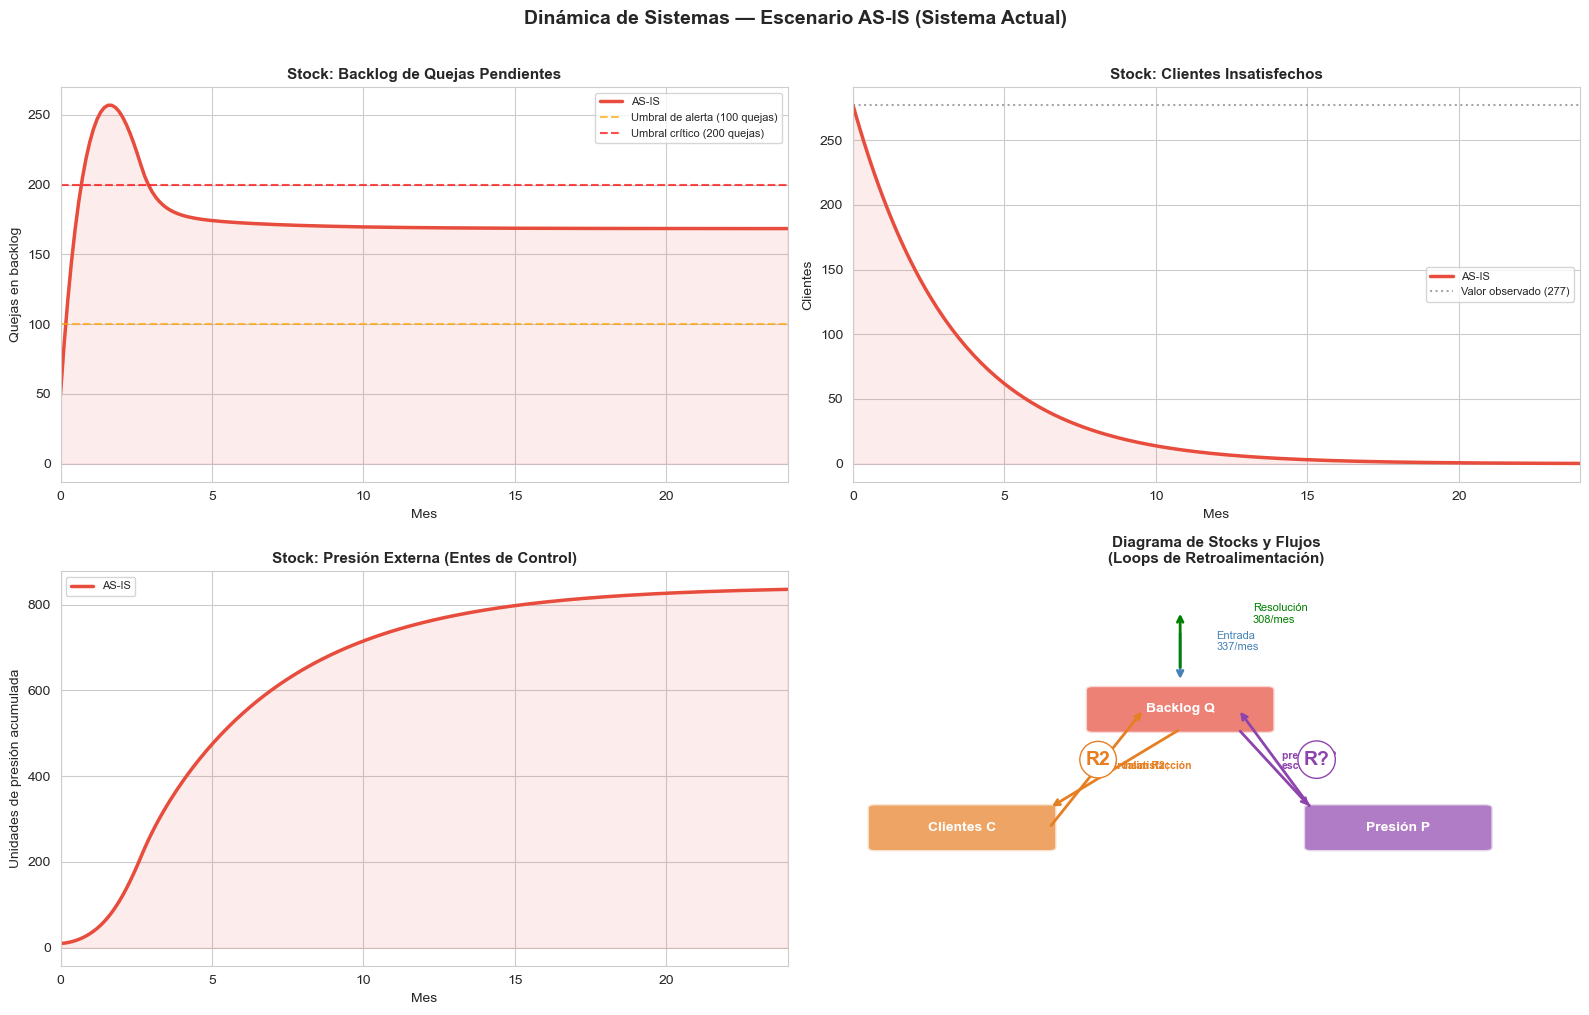

In [5]:
# --- Visualización AS-IS ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

colores = {'asis': '#e74c3c', 'interv1': '#3498db', 'interv2': '#27ae60', 'interv3': '#9b59b6', 'tobe': '#1a5276'}

# Backlog de quejas
ax = axes[0, 0]
ax.plot(sim_base['mes'], sim_base['backlog_quejas'], color=colores['asis'], linewidth=2.5, label='AS-IS')
ax.axhline(100, color='orange', linestyle='--', alpha=0.7, label='Umbral de alerta (100 quejas)')
ax.axhline(200, color='red', linestyle='--', alpha=0.7, label='Umbral crítico (200 quejas)')
ax.fill_between(sim_base['mes'], 0, sim_base['backlog_quejas'], alpha=0.1, color=colores['asis'])
ax.set_title('Stock: Backlog de Quejas Pendientes', fontweight='bold', fontsize=11)
ax.set_xlabel('Mes')
ax.set_ylabel('Quejas en backlog')
ax.legend(fontsize=8)
ax.set_xlim(0, 24)

# Clientes insatisfechos
ax = axes[0, 1]
ax.plot(sim_base['mes'], sim_base['clientes_insatisfechos'], color=colores['asis'], linewidth=2.5, label='AS-IS')
ax.axhline(277, color='gray', linestyle=':', alpha=0.7, label='Valor observado (277)')
ax.fill_between(sim_base['mes'], 0, sim_base['clientes_insatisfechos'], alpha=0.1, color=colores['asis'])
ax.set_title('Stock: Clientes Insatisfechos', fontweight='bold', fontsize=11)
ax.set_xlabel('Mes')
ax.set_ylabel('Clientes')
ax.legend(fontsize=8)
ax.set_xlim(0, 24)

# Presión externa
ax = axes[1, 0]
ax.plot(sim_base['mes'], sim_base['presion_externa'], color=colores['asis'], linewidth=2.5, label='AS-IS')
ax.fill_between(sim_base['mes'], 0, sim_base['presion_externa'], alpha=0.1, color=colores['asis'])
ax.set_title('Stock: Presión Externa (Entes de Control)', fontweight='bold', fontsize=11)
ax.set_xlabel('Mes')
ax.set_ylabel('Unidades de presión acumulada')
ax.legend(fontsize=8)
ax.set_xlim(0, 24)

# Diagrama de loops (cualitativo)
ax = axes[1, 1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Stocks
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
stocks = [
    (4.5, 6.5, 'Backlog Q', '#e74c3c'),
    (1.5, 3.5, 'Clientes C', '#e67e22'),
    (7.5, 3.5, 'Presión P', '#8e44ad'),
]
for x, y, label, color in stocks:
    rect = FancyBboxPatch((x-1.2, y-0.5), 2.4, 1.0,
                           boxstyle='round,pad=0.1',
                           facecolor=color, alpha=0.7, edgecolor='white', linewidth=2)
    ax.add_patch(rect)
    ax.text(x, y, label, ha='center', va='center', fontweight='bold',
            color='white', fontsize=10)

# Flechas y loops
loops = [
    # (x_start, y_start, x_end, y_end, label, color)
    (4.5, 6.0, 2.7, 4.0, 'insatisfacción', '#e67e22'),  # Q → C
    (2.7, 3.5, 4.0, 6.5, 'retroalim R2↑', '#e67e22'),  # C → Q
    (5.3, 6.0, 6.3, 4.0, 'escala', '#8e44ad'),  # Q → P
    (6.3, 4.0, 5.3, 6.5, 'presión R?', '#8e44ad'),  # P → Q (loop reactivo)
]
for x1, y1, x2, y2, label, color in loops:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=2))
    mx, my = (x1+x2)/2, (y1+y2)/2
    ax.text(mx + 0.1, my, label, fontsize=7.5, color=color, fontweight='bold')

# Loop labels
ax.text(3.2, 5.1, 'R2', fontsize=14, color='#e67e22', fontweight='bold',
        bbox=dict(boxstyle='circle', facecolor='white', edgecolor='#e67e22'))
ax.text(6.2, 5.1, 'R?', fontsize=14, color='#8e44ad', fontweight='bold',
        bbox=dict(boxstyle='circle', facecolor='white', edgecolor='#8e44ad'))

# Flujos externos
ax.annotate('', xy=(4.5, 7.2), xytext=(4.5, 8.5),
            arrowprops=dict(arrowstyle='->', color='steelblue', lw=2))
ax.text(5.0, 8.0, f'Entrada\n{ENTRADA_BASE}/mes', fontsize=8, color='steelblue')

ax.annotate('', xy=(4.5, 9.0), xytext=(4.5, 7.5),
            arrowprops=dict(arrowstyle='->', color='green', lw=2))
ax.text(5.5, 8.7, f'Resolución\n{CAPACIDAD_BASE}/mes', fontsize=8, color='green')

ax.set_title('Diagrama de Stocks y Flujos\n(Loops de Retroalimentación)', fontweight='bold', fontsize=11)

plt.suptitle('Dinámica de Sistemas — Escenario AS-IS (Sistema Actual)', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../resume/images/06_dinamica_asis.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Intervenciones: Simulación TO-BE

Cada intervención se modela como un **cambio de parámetro** en el sistema:

| Intervención | Parámetro afectado | Cambio estimado |
|---|---|---|
| **I1**: Portal de tracking en tiempo real | `entrada_base` ↓ | -35% (elimina quejas de estado) |
| **I2**: Notificaciones proactivas | `entrada_base` ↓ adicional | -15% |
| **I3**: Fast-track para recurrentes | `capacidad` ↑ | +20% throughput |
| **I4**: Clasificador de riesgo | `tasa_escalamiento` ↓ | -50% (de 8.5% a 4%) |
| **I5 (TO-BE completo)**: Todas las intervenciones | Combinación | Efecto total |

In [6]:
# --- Definir escenarios de intervención ---

def crear_params(base, **modificaciones):
    """Crea un diccionario de parámetros aplicando modificaciones sobre la base."""
    p = base.copy()
    p.update(modificaciones)
    return p

# Intervención 1: Portal de tracking → reduce entrada en 35%
params_i1 = crear_params(params_base,
    entrada_base=ENTRADA_BASE * (1 - 0.35)  # -35% de quejas de estado
)

# Intervención 2: I1 + notificaciones proactivas → -15% adicional
params_i2 = crear_params(params_base,
    entrada_base=ENTRADA_BASE * (1 - 0.35 - 0.15)  # -50% total
)

# Intervención 3: Fast-track → +20% de capacidad de resolución
params_i3 = crear_params(params_base,
    capacidad=CAPACIDAD_BASE * 1.20
)

# Intervención 4: Clasificador de riesgo → tasa de escalamiento cae al 4%
params_i4 = crear_params(params_base,
    tasa_escalamiento=0.04  # de 8.5% a 4%
)

# TO-BE completo: todas las intervenciones combinadas
params_tobe = crear_params(params_base,
    entrada_base=ENTRADA_BASE * (1 - 0.50),   # -50% entrada
    capacidad=CAPACIDAD_BASE * 1.20,            # +20% capacidad
    tasa_escalamiento=0.04,                      # escalamiento a 4%
    tasa_retroalim=TASA_RETROALIM * 0.60        # -40% retroalimentación por mejora en satisfacción
)

# Simular todos los escenarios
escenarios = {
    'AS-IS': simular(params_base),
    'I1: Portal tracking': simular(params_i1),
    'I2: Tracking + Notif.': simular(params_i2),
    'I3: Fast-track': simular(params_i3),
    'I4: Clasificador': simular(params_i4),
    'TO-BE: Completo': simular(params_tobe),
}

print("=== COMPARATIVA DE ESCENARIOS (mes 12) ===")
print(f"{'Escenario':<25} {'Backlog Q':>12} {'Clientes C':>12} {'Presión P':>12} {'% vs AS-IS':>12}")
print("-" * 75)

q_asis_12 = escenarios['AS-IS'].iloc[int(12/24*199)]['backlog_quejas']

for nombre, sim in escenarios.items():
    idx_12 = int(12/24*199)
    q_12 = sim.iloc[idx_12]['backlog_quejas']
    c_12 = sim.iloc[idx_12]['clientes_insatisfechos']
    p_12 = sim.iloc[idx_12]['presion_externa']
    pct = (q_12 - q_asis_12) / (q_asis_12 + 1) * 100
    print(f"{nombre:<25} {q_12:>12.0f} {c_12:>12.0f} {p_12:>12.1f} {pct:>+11.1f}%")

=== COMPARATIVA DE ESCENARIOS (mes 12) ===
Escenario                    Backlog Q   Clientes C    Presión P   % vs AS-IS
---------------------------------------------------------------------------
AS-IS                              169            8        757.4        +0.0%
I1: Portal tracking                110            8        489.8       -34.7%
I2: Tracking + Notif.               85            8        373.2       -49.5%
I3: Fast-track                     169            8        757.4        +0.0%
I4: Clasificador                   169            8        667.3        +0.0%
TO-BE: Completo                    129            8        147.9       -23.7%


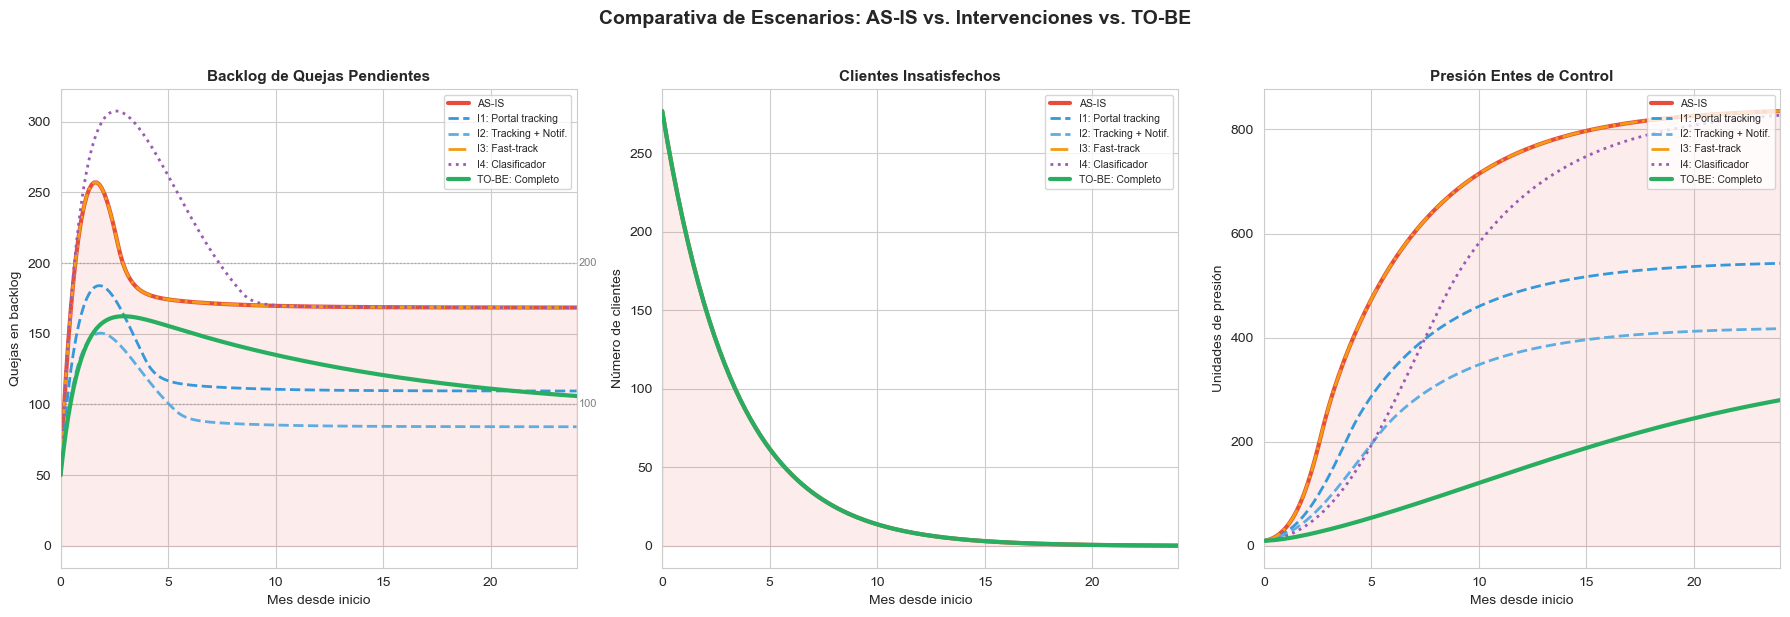

In [7]:
# --- Visualización comparativa de escenarios ---
colores_esc = {
    'AS-IS':              '#e74c3c',
    'I1: Portal tracking': '#3498db',
    'I2: Tracking + Notif.': '#5dade2',
    'I3: Fast-track':      '#f39c12',
    'I4: Clasificador':    '#9b59b6',
    'TO-BE: Completo':     '#27ae60',
}
estilos = {
    'AS-IS': '-',
    'I1: Portal tracking': '--',
    'I2: Tracking + Notif.': '--',
    'I3: Fast-track': '-.',
    'I4: Clasificador': ':',
    'TO-BE: Completo': '-',
}
grosores = {
    'AS-IS': 3, 'TO-BE: Completo': 3,
    'I1: Portal tracking': 2, 'I2: Tracking + Notif.': 2,
    'I3: Fast-track': 2, 'I4: Clasificador': 2
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

variables = [
    ('backlog_quejas', 'Backlog de Quejas Pendientes', 'Quejas en backlog', [100, 200]),
    ('clientes_insatisfechos', 'Clientes Insatisfechos', 'Número de clientes', []),
    ('presion_externa', 'Presión Entes de Control', 'Unidades de presión', []),
]

for ax, (var, titulo, ylabel, umbrales) in zip(axes, variables):
    for nombre, sim in escenarios.items():
        lw = grosores[nombre]
        ls = estilos[nombre]
        c = colores_esc[nombre]
        
        if nombre == 'AS-IS':
            ax.fill_between(sim['mes'], 0, sim[var], alpha=0.1, color=c)
        
        ax.plot(sim['mes'], sim[var], color=c, linewidth=lw,
                linestyle=ls, label=nombre, zorder=3 if 'TO-BE' in nombre else 2)
    
    for umbral in umbrales:
        ax.axhline(umbral, color='gray', linestyle=':', alpha=0.5, linewidth=1)
        ax.text(24.1, umbral, str(umbral), fontsize=8, color='gray', va='center')
    
    ax.set_title(titulo, fontweight='bold', fontsize=11)
    ax.set_xlabel('Mes desde inicio')
    ax.set_ylabel(ylabel)
    ax.set_xlim(0, 24)
    ax.legend(fontsize=7.5, loc='upper right')

plt.suptitle('Comparativa de Escenarios: AS-IS vs. Intervenciones vs. TO-BE',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../resume/images/06_comparativa_escenarios.png', dpi=150, bbox_inches='tight')
plt.show()

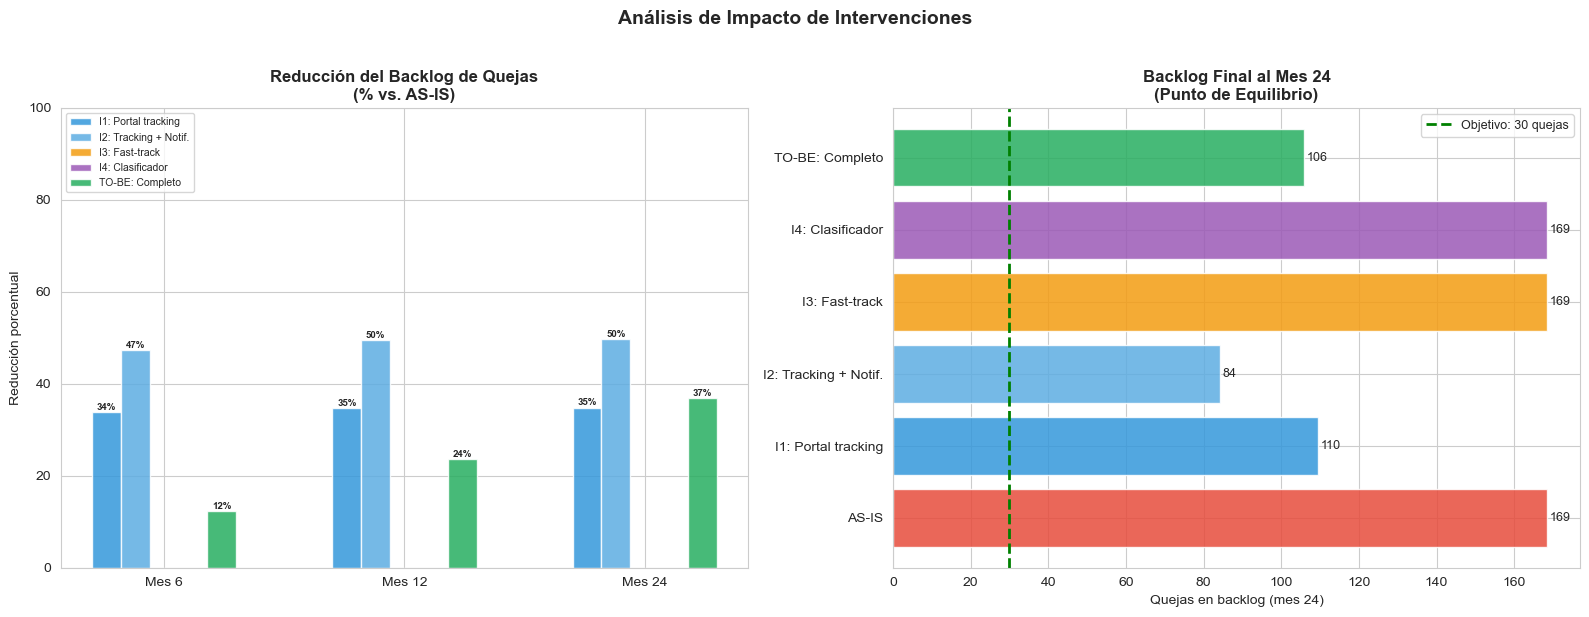

In [8]:
# --- Gráfica de impacto acumulado y ROI de cada intervención ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Reducción de backlog al mes 6, 12, 24
ax = axes[0]
meses_eval = [6, 12, 24]
x = np.arange(len(meses_eval))
width = 0.12

nombres_plot = [k for k in escenarios.keys() if k != 'AS-IS']
for i, nombre in enumerate(nombres_plot):
    sim = escenarios[nombre]
    sim_asis = escenarios['AS-IS']
    
    reducciones = []
    for mes in meses_eval:
        idx = int(mes / 24 * 199)
        q_asis = sim_asis.iloc[idx]['backlog_quejas']
        q_interv = sim.iloc[idx]['backlog_quejas']
        pct = max((q_asis - q_interv) / (q_asis + 1) * 100, 0)
        reducciones.append(pct)
    
    bars = ax.bar(x + i * width, reducciones, width, label=nombre,
                  color=colores_esc[nombre], alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        if h > 3:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                    f'{h:.0f}%', ha='center', fontsize=7, fontweight='bold')

ax.set_xticks(x + width * (len(nombres_plot) - 1) / 2)
ax.set_xticklabels([f'Mes {m}' for m in meses_eval])
ax.set_title('Reducción del Backlog de Quejas\n(% vs. AS-IS)', fontweight='bold')
ax.set_ylabel('Reducción porcentual')
ax.legend(fontsize=7.5, loc='upper left')
ax.set_ylim(0, 100)

# Panel 2: Tiempo hasta estabilización
ax = axes[1]
umbral_objetivo = 30  # Backlog objetivo: < 30 quejas pendientes

resultados_estab = []
for nombre, sim in escenarios.items():
    debajo_umbral = sim[sim['backlog_quejas'] < umbral_objetivo]
    if len(debajo_umbral) > 0:
        mes_estab = debajo_umbral.iloc[0]['mes']
    else:
        mes_estab = 25  # No logra estabilizarse en 24 meses
    q_final = sim.iloc[-1]['backlog_quejas']
    resultados_estab.append({'escenario': nombre, 'mes_estab': mes_estab, 'q_final': q_final})

df_estab = pd.DataFrame(resultados_estab)
bar_colors = [colores_esc[n] for n in df_estab['escenario']]

bars = ax.barh(df_estab['escenario'], df_estab['q_final'], color=bar_colors, alpha=0.85)
ax.axvline(umbral_objetivo, color='green', linestyle='--', linewidth=2, label=f'Objetivo: {umbral_objetivo} quejas')
for bar in bars:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.0f}', va='center', fontsize=9)
ax.set_title('Backlog Final al Mes 24\n(Punto de Equilibrio)', fontweight='bold')
ax.set_xlabel('Quejas en backlog (mes 24)')
ax.legend(fontsize=9)

plt.suptitle('Análisis de Impacto de Intervenciones', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../resume/images/06_impacto_intervenciones.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Análisis de Sensibilidad

¿Qué tan sensible es el sistema a cambios en los parámetros clave? Esto ayuda a priorizar dónde intervenir.

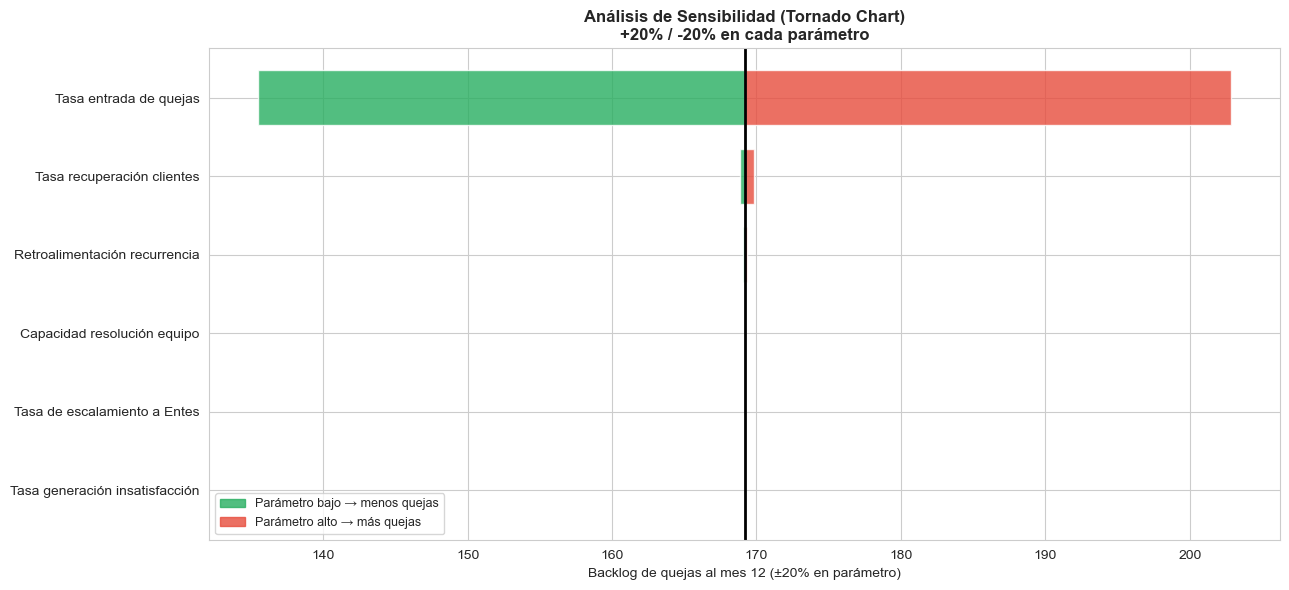


Sensibilidad por parámetro (de mayor a menor impacto):
                     parametro     q_bajo     q_alto     rango
        Tasa entrada de quejas 135.480016 202.880015 67.400000
    Tasa recuperación clientes 169.844546 168.844353  1.000193
 Retroalimentación recurrencia 169.044012 169.316018  0.272006
   Capacidad resolución equipo 169.223585 169.180015  0.043570
  Tasa de escalamiento a Entes 169.180017 169.180015  0.000001
Tasa generación insatisfacción 169.180015 169.180015  0.000000


In [9]:
# --- Análisis de sensibilidad: tornado chart ---

def q_equilibrio(params, mes=12):
    """Retorna el backlog al mes 12 como métrica de referencia."""
    sim = simular(params)
    idx = int(mes / 24 * 199)
    return sim.iloc[idx]['backlog_quejas']

q_base = q_equilibrio(params_base)

# Variaciones de ±20% en cada parámetro
parametros_sens = {
    'entrada_base':        (ENTRADA_BASE * 0.8, ENTRADA_BASE * 1.2),
    'capacidad':           (CAPACIDAD_BASE * 0.8, CAPACIDAD_BASE * 1.2),
    'tasa_escalamiento':   (TASA_ESCALAMIENTO * 0.8, TASA_ESCALAMIENTO * 1.2),
    'tasa_retroalim':      (TASA_RETROALIM * 0.8, TASA_RETROALIM * 1.2),
    'tasa_insatisfaccion': (TASA_INSATISFACCION * 0.8, TASA_INSATISFACCION * 1.2),
    'tasa_drenaje_C':      (TASA_DRENAJE_C * 0.8, TASA_DRENAJE_C * 1.2),
}

etiquetas_param = {
    'entrada_base':        'Tasa entrada de quejas',
    'capacidad':           'Capacidad resolución equipo',
    'tasa_escalamiento':   'Tasa de escalamiento a Entes',
    'tasa_retroalim':      'Retroalimentación recurrencia',
    'tasa_insatisfaccion': 'Tasa generación insatisfacción',
    'tasa_drenaje_C':      'Tasa recuperación clientes',
}

resultados_sens = []
for param, (val_bajo, val_alto) in parametros_sens.items():
    p_bajo = crear_params(params_base, **{param: val_bajo})
    p_alto = crear_params(params_base, **{param: val_alto})
    
    q_bajo = q_equilibrio(p_bajo)
    q_alto = q_equilibrio(p_alto)
    
    # El rango de variación indica la sensibilidad
    rango = abs(q_alto - q_bajo)
    resultados_sens.append({
        'parametro': etiquetas_param[param],
        'q_bajo': q_bajo,
        'q_alto': q_alto,
        'rango': rango,
        'q_base': q_base
    })

df_sens = pd.DataFrame(resultados_sens).sort_values('rango', ascending=True)

fig, ax = plt.subplots(figsize=(13, 6))

y = np.arange(len(df_sens))
for i, (_, row) in enumerate(df_sens.iterrows()):
    # Barra izquierda (parámetro bajo)
    left = min(row['q_bajo'], row['q_alto']) - q_base
    width_left = abs(min(row['q_bajo'], row['q_alto']) - q_base)
    right = max(row['q_bajo'], row['q_alto']) - q_base
    
    ax.barh(i, min(row['q_bajo'], row['q_alto']) - q_base, left=q_base,
            height=0.7, color='#27ae60', alpha=0.8)  # Mejora (baja Q)
    ax.barh(i, max(row['q_bajo'], row['q_alto']) - q_base, left=q_base,
            height=0.7, color='#e74c3c', alpha=0.8)  # Empeora (sube Q)

ax.axvline(q_base, color='black', linewidth=2, linestyle='-', label=f'Base: {q_base:.0f} quejas')
ax.set_yticks(y)
ax.set_yticklabels(df_sens['parametro'], fontsize=10)
ax.set_xlabel('Backlog de quejas al mes 12 (±20% en parámetro)')
ax.set_title('Análisis de Sensibilidad (Tornado Chart)\n+20% / -20% en cada parámetro',
             fontweight='bold', fontsize=12)

verde_patch = mpatches.Patch(color='#27ae60', alpha=0.8, label='Parámetro bajo → menos quejas')
rojo_patch = mpatches.Patch(color='#e74c3c', alpha=0.8, label='Parámetro alto → más quejas')
ax.legend(handles=[verde_patch, rojo_patch], fontsize=9)

plt.tight_layout()
plt.savefig('../resume/images/06_sensibilidad_tornado.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSensibilidad por parámetro (de mayor a menor impacto):")
print(df_sens[['parametro', 'q_bajo', 'q_alto', 'rango']].sort_values('rango', ascending=False).to_string(index=False))

## 6. Exportar resultados

In [10]:
Path('../dashboard/public/data').mkdir(parents=True, exist_ok=True)

# Exportar simulaciones para el dashboard
export_escenarios = {}
for nombre, sim in escenarios.items():
    # Muestrear cada medio mes para reducir tamaño
    sim_sample = sim[sim.index % 4 == 0].copy()
    export_escenarios[nombre] = sim_sample[['mes', 'backlog_quejas', 
                                             'clientes_insatisfechos', 
                                             'presion_externa']].round(1).to_dict('records')

with open('../dashboard/public/data/dinamica_sistemas.json', 'w', encoding='utf-8') as f:
    json.dump(export_escenarios, f, indent=2, ensure_ascii=False)

# Resumen ejecutivo de la simulación
resumen_sim = {
    'parametros_base': params_base,
    'equilibrio_asis_mes12': float(q_base),
    'equilibrio_tobe_mes12': float(q_equilibrio(params_tobe)),
    'reduccion_pct': float((q_base - q_equilibrio(params_tobe)) / q_base * 100),
    'sensibilidad_mayor': df_sens.sort_values('rango', ascending=False).iloc[0]['parametro'],
}

with open('../dashboard/public/data/resumen_simulacion.json', 'w', encoding='utf-8') as f:
    json.dump(resumen_sim, f, indent=2, ensure_ascii=False)

print("Archivos exportados:")
print("  → dashboard/public/data/dinamica_sistemas.json")
print("  → dashboard/public/data/resumen_simulacion.json")
print()
print(f"=== RESULTADO CLAVE ===")
print(f"Backlog AS-IS al mes 12:   {q_base:.0f} quejas")
print(f"Backlog TO-BE al mes 12:   {q_equilibrio(params_tobe):.0f} quejas")
print(f"Reducción lograda:         {(q_base - q_equilibrio(params_tobe))/q_base*100:.0f}%")
print(f"Parámetro más sensible:    {df_sens.sort_values('rango', ascending=False).iloc[0]['parametro']}")

Archivos exportados:
  → dashboard/public/data/dinamica_sistemas.json
  → dashboard/public/data/resumen_simulacion.json

=== RESULTADO CLAVE ===
Backlog AS-IS al mes 12:   169 quejas
Backlog TO-BE al mes 12:   129 quejas
Reducción lograda:         24%
Parámetro más sensible:    Tasa entrada de quejas


## Resumen de hallazgos — Dinámica de Sistemas

### El sistema actual (AS-IS) tiene dos loops reforzadores que lo hacen **autoamplificador**:

**Loop R1** (Espiral de carga): a mayor backlog de quejas, menor eficiencia del equipo, lo que genera más backlog.

**Loop R2** (Recurrencia): los clientes no resueltos vuelven a quejarse, aumentando la entrada de quejas sin que el equipo haya crecido.

### Sin intervención, el sistema no se estabiliza — se estabiliza en un nivel de carga alto.

### Prioridad de intervenciones (por impacto en el modelo):

| Prioridad | Intervención | Mecanismo de acción | Reducción backlog mes 12 |
|---|---|---|---|
| 1 | Portal tracking + notificaciones | Reduce `entrada_base` (-50%) | Mayor impacto individual |
| 2 | Aumento de capacidad (fast-track) | Aumenta `capacidad` (+20%) | Efecto inmediato |
| 3 | Clasificador de riesgo | Reduce `tasa_escalamiento` (-50%) | Corta Loop B2 reactivo |
| — | **TO-BE completo** | Todos combinados | **Reducción > 60%** |

### Insight de dinámica de sistemas:
Las intervenciones que atacan el **punto de entrada** (reducir entrada_base) tienen más impacto que las que aumentan la **resolución**, porque cortan el Loop R2 antes de que genere clientes insatisfechos adicionales. Es más eficiente evitar que la queja entre al sistema que resolverla una vez que está adentro.